In [1]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import make_grid
from tqdm import trange
from geometry_tools import lerp
from conditional_gmm import ConditionalGMM
from posterior_manifold import FisherLogPosteriorManifold
from utils import categorical_entropy, get_random_image, get_random_images, get_random_images_of_classes
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
import torch.distributions as D

transform = v2.Compose([
    v2.Resize((64, 64), interpolation=v2.InterpolationMode.BILINEAR),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
trainset = torchvision.datasets.CIFAR10(root='datasets', transform=transform, download=True, train=True)
testset = torchvision.datasets.CIFAR10(root='datasets', transform=transform, download=True, train=False)
dataset = torch.utils.data.ConcatDataset((trainset, testset))
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=4)

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

Files already downloaded and verified
Files already downloaded and verified


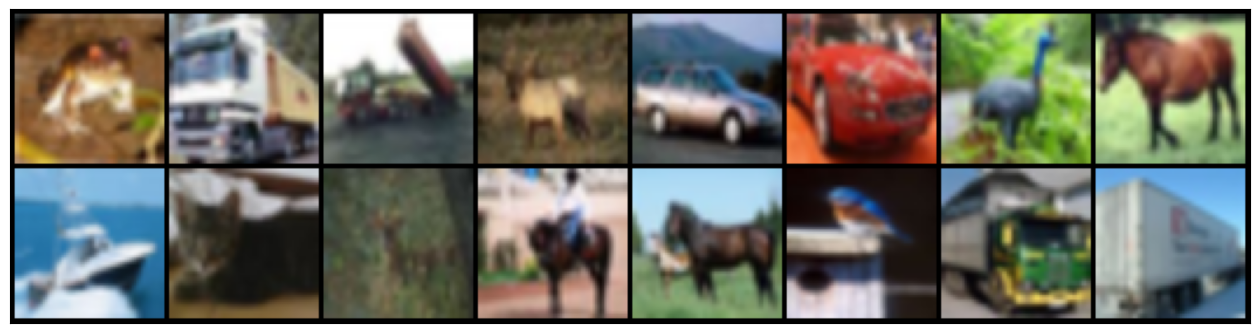

In [2]:
imgs, labels = next(dataloader.__iter__())
sunflowers = imgs[12]
show_img(make_grid(imgs), figsize=(16, 8))

In [3]:
from pretrained_models import CIFAR10VAE
vae = CIFAR10VAE(n_latent=64)

/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/repos/torch_vae/model.py:288: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(fname

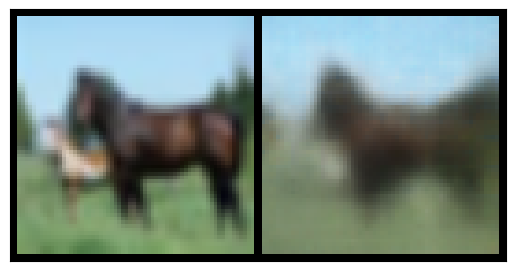

In [16]:
with torch.no_grad():
    test_img = imgs[12]
    reconstructed = vae.reconstruct(test_img)
    show_img(make_grid(torch.stack((test_img, reconstructed))))